In [1]:
import pandas as pd
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import seaborn as sns
import re
# Scikit 
from sklearn.model_selection import GroupShuffleSplit
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import ElasticNet
#Pytorch 
import torchvision
import torchaudio
import torch.nn as nn
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
# show the progress bar while priting
from tqdm import tqdm

import copy
import os
import joblib
#XGBoost
import xgboost as xgb



In [2]:
df = pd.read_csv("/Users/Thomas/Desktop/Master Thesis/Data/contract_snorkel_labeled.csv", 
low_memory=False)

In [3]:
df.head()

,Unnamed: 0.1,Unnamed: 0,contract_id,contract_number,contract_name,contract_status,contract_owner_cost_centre,terminated,term_type,start_date,...,global_esg_yes_votes,global_esg_no_votes,global_news_yes_votes,global_news_no_votes,global_market_yes_votes,global_market_no_votes,global_supplier_macro_yes_votes,global_supplier_macro_no_votes,logistics_specific_yes_votes,logistics_specific_no_votes
0,0,0,9675,9675,Bioreliance_Master_2018_MSA,published,7756,0,fixed,2018-05-21 00:00:00+00:00,...,0,0,0,0,0,0,0,0,0,0
1,1,1,9675,9675,Bioreliance_Master_2018_MSA,published,7756,0,fixed,2018-05-21 00:00:00+00:00,...,0,0,0,0,0,0,0,0,0,0
2,2,2,9675,9675,Bioreliance_Master_2018_MSA,published,7756,0,fixed,2018-05-21 00:00:00+00:00,...,0,0,0,0,0,0,0,0,0,0
3,3,3,9675,9675,Bioreliance_Master_2018_MSA,published,7756,0,fixed,2018-05-21 00:00:00+00:00,...,0,0,0,0,0,0,0,0,0,0
4,4,4,9675,9675,Bioreliance_Master_2018_MSA,published,7756,0,fixed,2018-05-21 00:00:00+00:00,...,0,0,0,0,0,0,1,0,0,0


In [4]:
print(df.shape)
print(f"Number of unique contracts: {df['contract_id'].nunique()}")
print(df.info())

(9201, 226)
Number of unique contracts: 2209
<class 'pandas.DataFrame'>
RangeIndex: 9201 entries, 0 to 9200
Columns: 226 entries, Unnamed: 0.1 to logistics_specific_no_votes
dtypes: float64(98), int64(84), str(44)
memory usage: 15.9 MB
None


# Number of unique contracts per department

In [5]:

contracts_per_department = (
    df
    .groupby("department", dropna=False)["contract_id"]
    .nunique()
    .reset_index(name="unique_contract_count")
    .sort_values("unique_contract_count", ascending=False)
)

print(contracts_per_department)

                                 department  unique_contract_count
3                         Devices & Needles                    476
5                  Drug Product Outsourcing                    300
6                Drug Substance Outsourcing                    298
10                       Packaging Material                    289
13                   Raw Materials & Energy                    281
12  Quality, Production Services & Supplies                    215
1             Bioprocessing & Raw Materials                    113
9                                 Logistics                     95
2              Bioprocessing and Excipients                     59
0          Alliance, Acquisitions & PPM CoE                     35
11           Purchasing Excellence External                     20
14                Strategic Sourcing US Hub                      9
7    Global Strategic Outsourcing & Devices                      8
8            HI Warehouse Expansion Program                   

# Rows pr. Department

In [6]:
rows_per_department = (
    df
    .groupby("department", dropna=False)
    .size()
    .reset_index(name="row_count")
    .sort_values("row_count", ascending=False)
)

print(rows_per_department)

                                 department  row_count
3                         Devices & Needles       2197
13                   Raw Materials & Energy       1555
10                       Packaging Material       1272
12  Quality, Production Services & Supplies       1044
6                Drug Substance Outsourcing        943
1             Bioprocessing & Raw Materials        679
5                  Drug Product Outsourcing        589
9                                 Logistics        283
0          Alliance, Acquisitions & PPM CoE        270
2              Bioprocessing and Excipients        218
11           Purchasing Excellence External         89
7    Global Strategic Outsourcing & Devices         23
8            HI Warehouse Expansion Program         20
14                Strategic Sourcing US Hub         15
4       Distribution, GxP services & Energy          2
15     Strategy, Sourcing & Negotiation CoE          2


# Number of unique contracts per department per year

In [7]:
contracts_per_department_year_pivot = (
    df
    .groupby(["department", "observation_year"], dropna=False)["contract_id"]
    .nunique()
    .unstack(fill_value=0)
)

print(contracts_per_department_year_pivot)

observation_year                         2015  2016  2017  2018  2019  2020  \
department                                                                    
Alliance, Acquisitions & PPM CoE           11    12    15    22    24    25   
Bioprocessing & Raw Materials              19    23    23    28    34    41   
Bioprocessing and Excipients                8     8     8    10    11    18   
Devices & Needles                          34    38    49    56    80   127   
Distribution, GxP services & Energy         0     0     0     0     0     0   
Drug Product Outsourcing                    1     1     1     1     6    11   
Drug Substance Outsourcing                 10    12    15    21    35    59   
Global Strategic Outsourcing & Devices      0     0     0     0     0     0   
HI Warehouse Expansion Program              0     0     0     0     0     0   
Logistics                                   5     5     9     9     9    10   
Packaging Material                         36    39 

# Stage 1: Mean Predictor, Linear BaseLine, XGBoost Baseline & MLP Baseline 

In [8]:
df_baseline = df.copy()

Target columns

In [9]:
target_col = "renegotiation_prob"
group_col = "contract_id"

Features to drop

In [ ]:
drop_cols = [
    "Unnamed: 0",
    "contract_id",
    "contract_number",
    "contract_name",
    "supplier_id",
    "supplier_number",
    "supplier_display_name",
    "moodys_bvd_id",
    "Company name Latin alphabet",
    "target_renegotiate",
    "start_date",
    "expiration_date",
    "renegotiation_prob",  
    "lf_yes_votes",
    "lf_no_votes",
    "lf_abstain_votes",
    "contract_name_lower",
]

In [11]:
feature_cols = [
    c for c in df_baseline.columns
    if c not in drop_cols + [target_col]
    and not c.endswith("_yes_votes")
    and not c.endswith("_no_votes")
]

X = df_baseline[feature_cols].copy()
y = df_baseline[target_col].astype(float).copy()
groups = df_baseline[group_col].copy()

Group splitting

In [12]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
train_idx, val_idx = next(gss.split(X, y, groups=groups))

X_train = X.iloc[train_idx].copy()
X_val = X.iloc[val_idx].copy()

y_train = y.iloc[train_idx].copy()
y_val = y.iloc[val_idx].copy()

train_groups = groups.iloc[train_idx].copy()
val_groups = groups.iloc[val_idx].copy()

print("Train rows:", X_train.shape[0])
print("Val rows:", X_val.shape[0])
print("Train unique contracts:", train_groups.nunique())
print("Val unique contracts:", val_groups.nunique())


Train rows: 7302
Val rows: 1899
Train unique contracts: 1767
Val unique contracts: 442


Evaluation function

In [13]:
def evaluate_predictions(y_true, y_pred, model_name="model"):
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    return pd.DataFrame({
        "model": [model_name],
        "rmse": [rmse],
        "mae": [mae],
        "r2": [r2],
        "pred_mean": [np.mean(y_pred)],
        "true_mean": [np.mean(y_true)]
    })

### Define what is numerical and categorical columns

In [14]:
numeric_cols = X_train.select_dtypes(include=["int64", "float64", "bool"]).columns.tolist()
categorical_cols = X_train.select_dtypes(include=["object", "string", "str"]).columns.tolist()

print("Numeric columns:", len(numeric_cols))
print("Categorical columns:", len(categorical_cols))

Numeric columns: 159
Categorical columns: 36


### Preprocssesing

In [15]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols),
    ]
)

Creating a list to store results from baseline models

In [16]:
baseline_results_list = []

baseline_val_predictions = pd.DataFrame({
    "contract_id": val_groups.values,
    "y_true": y_val.values
})

print(baseline_val_predictions.head())

   contract_id    y_true
0         8157  0.472363
1         8157  0.472363
2         8157  0.472363
3         8157  0.472363
4         8157  0.166042


## Mean predictor

In [17]:
train_mean = y_train.mean()
y_pred_mean = np.full(shape=len(y_val), fill_value=train_mean)

results_mean = evaluate_predictions(
    y_true=y_val,
    y_pred=y_pred_mean,
    model_name="Mean Predictor"
)

baseline_results_list.append(results_mean)
baseline_val_predictions["mean_predictor"] = y_pred_mean

print(results_mean)

            model     rmse       mae        r2  pred_mean  true_mean
0  Mean Predictor  0.30465  0.242176 -0.008325   0.528869   0.556551


## ElasticNet

In [18]:
elastic_net = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", ElasticNet(alpha=0.01, l1_ratio=0.5, max_iter=10000, random_state=42))
])

elastic_net.fit(X_train, y_train)
y_pred_enet = elastic_net.predict(X_val)

# Keep predictions within [0, 1]
y_pred_enet = np.clip(y_pred_enet, 0, 1)

results_enet = evaluate_predictions(
    y_true=y_val,
    y_pred=y_pred_enet,
    model_name="Elastic Net"
)

baseline_results_list.append(results_enet)
baseline_val_predictions["elastic_net"] = y_pred_enet

print(results_enet)

/Users/Thomas/Desktop/Master Thesis/.venv/lib/python3.14/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['has_environmental_appendix']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


         model     rmse       mae        r2  pred_mean  true_mean
0  Elastic Net  0.15725  0.119528  0.731355    0.54422   0.556551


/Users/Thomas/Desktop/Master Thesis/.venv/lib/python3.14/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['has_environmental_appendix']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


## MLP baseline

### Transform into Matricies & Dataloaders

In [19]:
X_train_proc = preprocessor.fit_transform(X_train)
X_val_proc = preprocessor.transform(X_val)

# convert sparse -> dense if needed
if hasattr(X_train_proc, "toarray"):
    X_train_proc = X_train_proc.toarray()
    X_val_proc = X_val_proc.toarray()

X_train_tensor = torch.tensor(X_train_proc, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val_proc, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.float32).view(-1, 1)

/Users/Thomas/Desktop/Master Thesis/.venv/lib/python3.14/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['has_environmental_appendix']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/Users/Thomas/Desktop/Master Thesis/.venv/lib/python3.14/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['has_environmental_appendix']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


In [20]:
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=256, shuffle=False)

### MLP

In [21]:
class TabularMLP(nn.Module):
    def __init__(self, input_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.net(x)

# ------------------------------------------------------------
# Initialize model
# ------------------------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = TabularMLP(input_dim=X_train_tensor.shape[1]).to(device)

# Soft-label binary cross-entropy on logits
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-5
)  # we should try changing around with the optimizer later

# ------------------------------------------------------------
# Evaluation function
# ------------------------------------------------------------
def evaluate_mlp(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    preds = []
    targets = []

    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)

            logits = model(xb)
            loss = criterion(logits, yb)
            total_loss += loss.item() * xb.size(0)

            probs = torch.sigmoid(logits)

            preds.append(probs.cpu().numpy())
            targets.append(yb.cpu().numpy())

    preds = np.vstack(preds).ravel()
    targets = np.vstack(targets).ravel()

    avg_loss = total_loss / len(loader.dataset)
    rmse = mean_squared_error(targets, preds) ** 0.5
    mae = mean_absolute_error(targets, preds)

    return avg_loss, rmse, mae

# ------------------------------------------------------------
# Training loop with early stopping
# ------------------------------------------------------------
best_val_loss = float("inf")
best_state_dict = None
patience = 5
patience_counter = 0

train_losses = []
val_losses = []
val_rmses = []
val_maes = []

n_epochs = 50

for epoch in range(n_epochs):
    model.train()
    running_loss = 0.0

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()

        logits = model(xb)
        loss = criterion(logits, yb)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * xb.size(0)

    train_loss = running_loss / len(train_loader.dataset)
    val_loss, val_rmse, val_mae = evaluate_mlp(model, val_loader, criterion, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_rmses.append(val_rmse)
    val_maes.append(val_mae)

    print(
        f"Epoch {epoch + 1:02d} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val RMSE: {val_rmse:.4f} | "
        f"Val MAE: {val_mae:.4f}"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state_dict = copy.deepcopy(model.state_dict())
        patience_counter = 0
    else:
        patience_counter += 1

    if patience_counter >= patience:
        print(f"Early stopping triggered at epoch {epoch + 1}")
        break

# ------------------------------------------------------------
# Restore best model
# ------------------------------------------------------------
if best_state_dict is not None:
    model.load_state_dict(best_state_dict)

# ------------------------------------------------------------
# Save pretrained model + fitted preprocessor in memory and locally
# ------------------------------------------------------------
pretrained_mlp_state_dict = copy.deepcopy(model.state_dict())

save_dir = "models"
os.makedirs(save_dir, exist_ok=True)

# Save model weights
mlp_model_path = os.path.join(save_dir, "mlp_pretrained.pt")
torch.save(pretrained_mlp_state_dict, mlp_model_path)

# Save fitted preprocessor
preprocessor_path = os.path.join(save_dir, "mlp_preprocessor.joblib")
joblib.dump(preprocessor, preprocessor_path)

print(f"Saved pretrained MLP locally to: {mlp_model_path}")
print(f"Saved preprocessor locally to: {preprocessor_path}")
print("Pretrained MLP also stored in memory as: pretrained_mlp_state_dict")

# ------------------------------------------------------------
# Final validation predictions from best model
# ------------------------------------------------------------
model.eval()
mlp_preds = []

with torch.no_grad():
    for xb, yb in val_loader:
        xb = xb.to(device)

        logits = model(xb)
        probs = torch.sigmoid(logits)

        mlp_preds.append(probs.cpu().numpy())

y_pred_mlp = np.vstack(mlp_preds).ravel()

# ------------------------------------------------------------
# Add MLP to baseline comparison
# ------------------------------------------------------------
results_mlp = evaluate_predictions(
    y_true=y_val,
    y_pred=y_pred_mlp,
    model_name="MLP"
)

baseline_results_list.append(results_mlp)
baseline_val_predictions["mlp"] = y_pred_mlp

print(results_mlp)

# ------------------------------------------------------------
# Store training history
# ------------------------------------------------------------
mlp_training_history = pd.DataFrame({
    "epoch": range(1, len(train_losses) + 1),
    "train_loss": train_losses,
    "val_loss": val_losses,
    "val_rmse": val_rmses,
    "val_mae": val_maes
})

mlp_history_path = os.path.join(save_dir, "mlp_training_history.csv")
mlp_training_history.to_csv(mlp_history_path, index=False)

print(f"Saved MLP training history locally to: {mlp_history_path}")
print(mlp_training_history.head())

Epoch 01 | Train Loss: 0.6057 | Val Loss: 0.5581 | Val RMSE: 0.1525 | Val MAE: 0.1180
Epoch 02 | Train Loss: 0.5260 | Val Loss: 0.5438 | Val RMSE: 0.1122 | Val MAE: 0.0742
Epoch 03 | Train Loss: 0.5023 | Val Loss: 0.5517 | Val RMSE: 0.0978 | Val MAE: 0.0516
Epoch 04 | Train Loss: 0.4919 | Val Loss: 0.4940 | Val RMSE: 0.0870 | Val MAE: 0.0408
Epoch 05 | Train Loss: 0.4870 | Val Loss: 0.5031 | Val RMSE: 0.0770 | Val MAE: 0.0351
Epoch 06 | Train Loss: 0.4803 | Val Loss: 0.5479 | Val RMSE: 0.0858 | Val MAE: 0.0331
Epoch 07 | Train Loss: 0.4794 | Val Loss: 0.5621 | Val RMSE: 0.0692 | Val MAE: 0.0296
Epoch 08 | Train Loss: 0.4756 | Val Loss: 0.4788 | Val RMSE: 0.0781 | Val MAE: 0.0290
Epoch 09 | Train Loss: 0.4753 | Val Loss: 0.5209 | Val RMSE: 0.0626 | Val MAE: 0.0244
Epoch 10 | Train Loss: 0.4728 | Val Loss: 0.4754 | Val RMSE: 0.0584 | Val MAE: 0.0222
Epoch 11 | Train Loss: 0.4723 | Val Loss: 0.4747 | Val RMSE: 0.0730 | Val MAE: 0.0248
Epoch 12 | Train Loss: 0.4713 | Val Loss: 0.4580 | Val

## XGboost

https://xgboosting.com/

In [22]:
numeric_transformer_xgb = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer_xgb = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor_xgb = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_xgb, numeric_cols),
        ("cat", categorical_transformer_xgb, categorical_cols),
    ]
)

In [23]:
xgb_model = Pipeline(steps=[
    ("preprocessor", preprocessor_xgb),
    ("model", xgb.XGBRegressor(
        objective="reg:squarederror",
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        min_child_weight=3,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.0,
        reg_lambda=1.0,
        random_state=42,
        n_jobs=-1
    ))
])

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_val)
y_pred_xgb = np.clip(y_pred_xgb, 0, 1)

results_xgb = evaluate_predictions(
    y_true=y_val,
    y_pred=y_pred_xgb,
    model_name="XGBoost"
)

baseline_results_list.append(results_xgb)
baseline_val_predictions["xgboost"] = y_pred_xgb

print(results_xgb)

/Users/Thomas/Desktop/Master Thesis/.venv/lib/python3.14/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['has_environmental_appendix']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


     model      rmse       mae        r2  pred_mean  true_mean
0  XGBoost  0.017677  0.006202  0.996605   0.556941   0.556551


/Users/Thomas/Desktop/Master Thesis/.venv/lib/python3.14/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['has_environmental_appendix']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


In [24]:
# Get trained xgboost model out of pipeline
xgb_fitted = xgb_model.named_steps["model"]
xgb_preprocessor = xgb_model.named_steps["preprocessor"]

# Get transformed feature names
feature_names = xgb_preprocessor.get_feature_names_out()

# Build importance table
xgb_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": xgb_fitted.feature_importances_
}).sort_values("importance", ascending=False)

print(xgb_importance.head(50))

                                               feature  importance
14                             num__contract_age_years    0.173299
116             num__fin_flag_moderate_or_worse_rating    0.143531
100                              num__Tracking_Tracing    0.126746
103               num__fin_implied_rating_missing_flag    0.124700
104                   num__fin_risk_level_missing_flag    0.091032
7                                      num__start_year    0.040930
96                                        num__Customs    0.031017
411                         cat__expiry_range_180 days    0.020394
12                               num__observation_year    0.018878
142    num__fin_flag_multiple_financial_stress_signals    0.015813
5                               num__days_until_expiry    0.015512
143              num__fin_flag_severe_financial_stress    0.015415
8                                     num__expiry_year    0.013177
141                        num__fin_total_stress_flags    0.01

## Compare baseline predictions

In [25]:
baseline_results = pd.concat(baseline_results_list, ignore_index=True)
baseline_results = baseline_results.sort_values("mae", ascending=True).reset_index(drop=True)

print(baseline_results)
print(baseline_val_predictions.head())

            model      rmse       mae        r2  pred_mean  true_mean
0         XGBoost  0.017677  0.006202  0.996605   0.556941   0.556551
1             MLP  0.067999  0.024659  0.949765   0.570110   0.556551
2     Elastic Net  0.157250  0.119528  0.731355   0.544220   0.556551
3  Mean Predictor  0.304650  0.242176 -0.008325   0.528869   0.556551
   contract_id    y_true  mean_predictor  elastic_net       mlp   xgboost
0         8157  0.472363        0.528869     0.425072  0.483588  0.469722
1         8157  0.472363        0.528869     0.477652  0.482505  0.465793
2         8157  0.472363        0.528869     0.530232  0.481649  0.465341
3         8157  0.472363        0.528869     0.582812  0.469504  0.463488
4         8157  0.166042        0.528869     0.383345  0.169298  0.176347


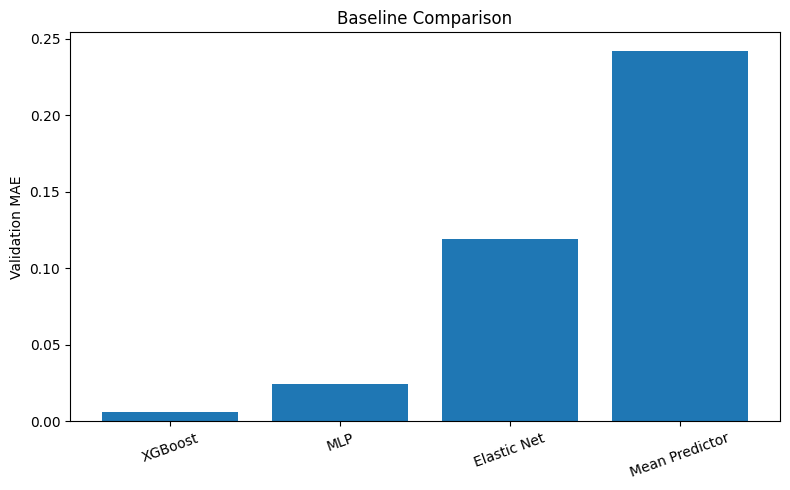

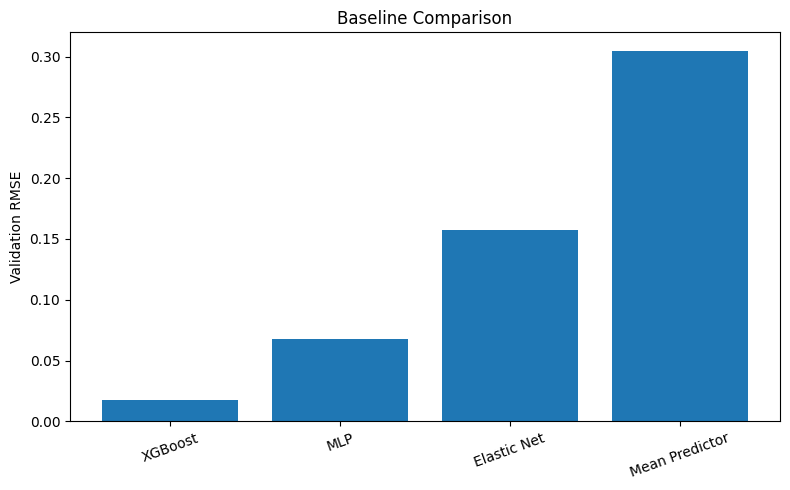

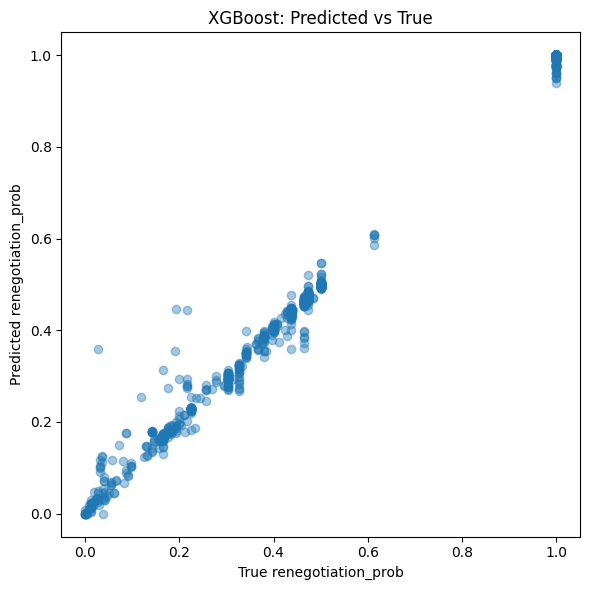

In [26]:
plot_df = baseline_results.sort_values("mae", ascending=True)

plt.figure(figsize=(8, 5))
plt.bar(plot_df["model"], plot_df["mae"])
plt.ylabel("Validation MAE")
plt.title("Baseline Comparison")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(plot_df["model"], plot_df["rmse"])
plt.ylabel("Validation RMSE")
plt.title("Baseline Comparison")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 6))
plt.scatter(y_val, y_pred_xgb, alpha=0.4)
plt.xlabel("True renegotiation_prob")
plt.ylabel("Predicted renegotiation_prob")
plt.title("XGBoost: Predicted vs True")
plt.tight_layout()
plt.show()

# Stage 2: Pre-trained MLP+finetuning, Pretrained MLP + MAML or FOMAML, MALP on logistics & Pooled Gold label MLP  - Test also with XGBoost on gold labels

Phase 1: Baselines on Stage A
Train Mean, Elastic Net, MLP, XGBoost on probabilistic labels.
Evaluate using both classification and calibration metrics; report per-department results.

Phase 2: Transfer-learning baseline
Fine-tune the Stage A MLP on Logistics gold data.
Assess classification and calibration; compare with Stage A baselines.

Phase 3: Meta-learning phase
Train MAML/FOMAML/ANIL using gold-labeled departments (excluding degenerate ones) to obtain θ.
Adapt to Logistics with a small support set and evaluate on a Logistics query set.
Optionally compare Logistics as a held-out test vs. Logistics included in meta-training.

Phase 4: Ablations
Random vs weak-pretrained initialization.
Inner-loop steps and learning-rate sensitivity.
Inclusion vs exclusion of weak signals in Stage B.
Hard labels vs probabilistic labels in Stage B (if feasible).

Phase 5: Sensitivity to imbalances
Analyze department-level and label-level imbalances and report their impact on performance and calibration.

Stage A baselines (trained on weak labels) as a baseline.
Direct fine-tuning of the Stage A model on Logistics gold data (transfer learning baseline).
MAML-based strategies (full MAML, FOMAML, ANIL) where the meta-learner is optimized across multiple departments and then a few-shot adaptation is performed for Logistics (or another target department).
The crux is to make the distinctions explicit in your experiments and to clearly report which methods are used for initialization, which are adapted per department, and how performance transfers across tasks. This aligns with established practice in meta-learning research and provides a rigorous empirical comparison for your Master’s thesis (Vanschoren, 2019; Lee et al., 2024; Jiang et al., 2021).

Detailed guidance for your thesis setup

1) Clarify the two learning tracks in your design

Track A: Weak supervision baseline

Stage A: Train four baselines on the Snorkel-produced probabilistic labels for all contracts.

Output: a strong weakly supervised model (or set of models) with calibrated probabilities.

Purpose: establish a competitive baseline and a solid initialization for comparisons.

Track B: Department-adapted learning strategies

Option B1 (Transfer-learning baseline): Take the Stage A pre-trained MLP and fine-tune it on Logistics gold labels using a standard supervised objective. Include calibration adjustments if needed.

Option B2 (MAML-based meta-learning): Train a meta-initialization θ across multiple gold-labeled departments, then adapt to Logistics with a small support set (5 yes/5 no or as available). Compare full MAML, FOMAML, and ANIL variants.

Option B3 (Hybrid): Pre-train with Stage A, then perform a light MAML stage using Logistics plus a subset of other gold-labeled departments to assess improvement in rapid adaptation.

	•	does few-shot adaptation help?
	•	does MAML beat plain fine-tuning?
XGboost?

	•	maybe MAML beats fine-tuning
	•	but does it beat a strong non-neural tabular baseline?


	• Stage 1: Who best learns the weak-label signal?
	•	Stage 2: Does meta-learning improve target-department adaptation over ordinary transfer learning?
	•	Gold-label benchmark question: How does the neural adaptation framework compare to a strong tabular non-meta model like XGBoost?


Figure X. Few-shot adaptation to the Logistics department.

(A) Support/query split at contract level.

(B) Distribution of predicted renegotiation scores on the Logistics query set before and after adaptation.

(C) Ranked query contracts with true gold labels highlighted, comparing fine-tuning and MAML.

(D) Precision@K across competing methods, showing the effectiveness of top-K contract prioritization.

# MAMAL

https://www.tahabouhsine.com/flaxdocs/research/meta-learning